# DevPulse — Week 1: GH Archive Exploration
## 1. Project Introduction
Explore historical public GitHub activity using a bounded real-data sample.
This notebook establishes the data contract for later distributed engineering.
All numbers below describe the selected input and sample, not all GitHub activity.

## 2. GH Archive Dataset Overview
[GH Archive](https://www.gharchive.org/) stores hourly compressed newline-delimited
JSON events from GitHub's public event stream. Archive hours are UTC and filenames
use an unpadded hour. Nested `payload` properties depend on the event type.
The sample metadata records the source URL, checksum, seed, and scanned record count.

## 3. Environment Setup and Imports
Run with this project's virtual-environment kernel. Paths work from the repository
root or its `notebooks/` directory. Java is configured locally when Spark starts.

In [1]:
from pathlib import Path
import json
import sys
from IPython.display import display, Markdown, Image
import pandas as pd

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'config/settings.py').exists() and (p / 'notebooks').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Launch from the DevPulse project or its notebooks directory')
sys.path.insert(0, str(ROOT))
from config.settings import SAMPLE_PATH, PROCESSED_DIR, CHART_DIR
from exploration.io import iter_events
from exploration.explore_dataset import analyze_records, run_analysis
from exploration.schema_inspection import extract_schema
from exploration.spark_demo import run_spark_demo
from scripts.environment_info import collect_environment
environment = collect_environment()
display(pd.Series({k: environment[k] for k in ['os', 'architecture', 'python', 'virtual_environment', 'java_version']}))
display(pd.Series(environment['packages'], name='Installed version'))

os                                          macOS-27.0.1-arm64-arm-64bit
architecture                                                       arm64
python                 3.12.14 (main, Aug 25 2026, 13:50:33) [Clang 2...
virtual_environment                                                 True
java_version           openjdk version "17.0.20.1" 2026-08-18\nOpenJD...
dtype: object

pyspark        4.0.1
pandas         2.3.3
numpy          2.2.6
matplotlib    3.10.7
jupyterlab    4.4.10
requests      2.32.5
pytest         8.4.2
nbclient      0.10.2
Name: Installed version, dtype: object

## 4. Loading the Dataset
First run the downloader and schema-inspection commands in the README. The default
10,000-event reservoir sample is selected uniformly from the entire downloaded hour
using seed 42, rather than taking only the beginning of the file. Nested JSON is preserved.

In [2]:
if not SAMPLE_PATH.exists():
    raise FileNotFoundError('Generate data/samples/github_events_sample.jsonl using schema_inspection first')
metadata = json.loads(SAMPLE_PATH.with_suffix('.metadata.json').read_text())
records = []
for event in iter_events(SAMPLE_PATH):
    records.append(event)
    if len(records) > 100000:
        raise ValueError('Notebook sample exceeds its 100,000-record memory cap')
frame, summary, tables = analyze_records(records)
display(pd.Series({k: metadata[k] for k in ['scope', 'data_origin', 'sampling_method', 'seed', 'sample_records', 'valid_source_records']}))
display(pd.DataFrame(metadata['sources']))

scope                                                              sample
data_origin                                               real GH Archive
sampling_method         uniform reservoir without replacement, retaine...
seed                                                                   42
sample_records                                                      10000
valid_source_records                                               223540
dtype: object

,path,bytes,sha256,read_stats,verified_gharchive_download,url
0,data/raw/2025-01-01-12.json.gz,76173404,db6cbf53e3c9d40590a45414d42869d22b6fe0f9faa20f...,"{'lines': 223540, 'valid_records': 223540, 'in...",True,https://data.gharchive.org/2025-01-01-12.json.gz


## 5. Exploring the JSON Structure
Common properties identify the event, account, repository, time, visibility, and
payload. Optional `org` and payload-specific paths vary. A field absent for unrelated
event types is not automatically a quality defect. Array paths use `[]`.

In [3]:
schema = extract_schema(records)
print(json.dumps(records[0], indent=2)[:8000])
display(pd.DataFrame(schema['fields']).T.head(30))
display(pd.DataFrame(schema['important_fields']).T)

{
  "id": "45191299339",
  "type": "PushEvent",
  "actor": {
    "id": 157595799,
    "login": "Bogdan4308",
    "display_login": "Bogdan4308",
    "gravatar_id": "",
    "url": "https://api.github.com/users/Bogdan4308",
    "avatar_url": "https://avatars.githubusercontent.com/u/157595799?"
  },
  "repo": {
    "id": 843767409,
    "name": "Bogdan4308/Krokus",
    "url": "https://api.github.com/repos/Bogdan4308/Krokus"
  },
  "payload": {
    "repository_id": 843767409,
    "push_id": 21932045552,
    "size": 1,
    "distinct_size": 1,
    "ref": "refs/heads/PlayersInfo",
    "head": "c1cd7e2aad8cb0c0fa7dc9c310e4242084a78308",
    "before": "fae8a2ec9b7bfe73808d4573c5d1edbdaacc000d",
    "commits": [
      {
        "sha": "c1cd7e2aad8cb0c0fa7dc9c310e4242084a78308",
        "author": {
          "email": "157595799+Bogdan4308@users.noreply.github.com",
          "name": "Bogdan4308"
        },
        "message": "\u0424\u0430\u0439\u043b \u043e\u043d\u043e\u0432\u043b\u0435\u043d\u043e

,present_records,absent_records,types_per_record
actor,10000,0,{'object': 10000}
actor.avatar_url,10000,0,{'string': 10000}
actor.display_login,10000,0,{'string': 10000}
actor.gravatar_id,10000,0,{'string': 10000}
actor.id,10000,0,{'integer': 10000}
actor.login,10000,0,{'string': 10000}
actor.url,10000,0,{'string': 10000}
created_at,10000,0,{'string': 10000}
id,10000,0,{'string': 10000}
org,1546,8454,{'object': 1546}


,missing,null
id,0,0
type,0,0
actor.id,0,0
actor.login,0,0
repo.id,0,0
repo.name,0,0
created_at,0,0
public,0,0
payload,0,0


## 6. Understanding GitHub Event Types
| Event | Meaning and useful payload examples |
|---|---|
| PushEvent | A push; `ref`, `head`, `before`, and historically `commits`/`size` may appear |
| WatchEvent | Starring action, commonly `action=started` |
| ForkEvent | A fork; `forkee` may contain repository metadata |
| IssuesEvent | Issue lifecycle; `action`, `issue` |
| PullRequestEvent | Pull request lifecycle; `action`, `number`, `pull_request` |
| CreateEvent | Repository/branch/tag creation; `ref_type`, `ref` |
| IssueCommentEvent | Comment lifecycle; `action`, `issue`, `comment` |
| PullRequestReviewEvent | Review lifecycle; `action`, `review`, `pull_request` |

Payload examples are optional, historical, and schema-dependent. Consult the actual
schema output and [GitHub's event documentation](https://docs.github.com/en/rest/using-the-rest-api/github-event-types).
Counts measure observed events, not commits, currently accumulated stars, or unique actions after deduplication.

In [4]:
display(tables['event_types'].sort_values('events', ascending=False))
for event_type in ['PushEvent', 'WatchEvent', 'ForkEvent', 'IssuesEvent',
                   'PullRequestEvent', 'CreateEvent', 'IssueCommentEvent', 'PullRequestReviewEvent']:
    example = next((r for r in records if r.get('type') == event_type), None)
    print(event_type, ':', list(example.get('payload', {})) if example else 'Not observed in this sample')

,event_type,events
12,PushEvent,7585
1,CreateEvent,812
9,PullRequestEvent,495
14,WatchEvent,396
5,IssueCommentEvent,225
2,DeleteEvent,187
3,ForkEvent,72
11,PullRequestReviewEvent,67
6,IssuesEvent,66
13,ReleaseEvent,27


PushEvent : ['repository_id', 'push_id', 'size', 'distinct_size', 'ref', 'head', 'before', 'commits']
WatchEvent : ['action']
ForkEvent : ['forkee']
IssuesEvent : ['action', 'issue']
PullRequestEvent : ['action', 'number', 'pull_request']
CreateEvent : ['ref', 'ref_type', 'master_branch', 'description', 'pusher_type']
IssueCommentEvent : ['action', 'issue', 'comment']
PullRequestReviewEvent : ['action', 'review', 'pull_request']


## 7. Data Quality Analysis
Missing values are reported separately as absent, null, and blank. Duplicate metrics
distinguish duplicated identifiers from excess records. Rankings retain raw event
counts; this Week 1 step diagnoses duplicates rather than silently deleting records.
Invalid timestamps are excluded from time-based aggregates and counted explicitly.

In [5]:
display(tables['missing_values'])
display(pd.Series({k: summary[k] for k in ['duplicate_event_ids', 'duplicate_excess_records',
                'records_with_duplicated_ids', 'invalid_or_missing_timestamps']}))
display(tables['duplicate_ids'].head(10))

,field,absent,null,blank,missing_total,missing_percent
0,id,0,0,0,0,0.0
1,type,0,0,0,0,0.0
2,actor.id,0,0,0,0,0.0
3,actor.login,0,0,0,0,0.0
4,repo.id,0,0,0,0,0.0
5,repo.name,0,0,0,0,0.0
6,created_at,0,0,0,0,0.0
7,public,0,0,0,0,0.0
8,payload,0,0,0,0,0.0


duplicate_event_ids              0
duplicate_excess_records         0
records_with_duplicated_ids      0
invalid_or_missing_timestamps    0
dtype: int64

,event_id,occurrences


## 8. Repository Activity Analysis
Repositories are grouped by ID, so an observed rename does not split the count.
The latest observed nonnull name labels each group. High event volume measures activity
in this sample and does not establish that a repository is trending.

In [6]:
display(pd.Series({'Unique repository IDs': summary['unique_repositories_by_id']}))
display(tables['repositories'].head(10))

Unique repository IDs    8247
dtype: int64

,id,events,name
0,222505696,86,brand22/d3
1,818567109,74,frdpzk2/ppub
2,910454393,49,frdpzk3/ppub
3,895347228,47,CelestiaNFT/Welcome-NFT
4,800371228,34,iniadittt/iniadittt
5,892938900,34,SoliSpirit/proxy-list
6,910264522,32,Raihan-Fadillah/database
7,893638857,31,Farrit1184/Klipper-backup
8,881419220,27,freecall2019/day
9,437227236,24,adi224foreverg/globaldl


## 9. Developer Activity Analysis
Public account activity includes automation and bot accounts. Event counts cannot
measure a person's productivity. Stable actor IDs define distinct accounts; login
names can change. The table includes only events with `public=true`.

In [7]:
display(pd.Series({'Unique account IDs': summary['unique_accounts_by_id'],
                  'Unique public account IDs': summary['unique_public_accounts_by_id']}))
display(tables['public_accounts'].head(10))
display(tables['utc_hour_distribution'])

Unique account IDs           3738
Unique public account IDs    3738
dtype: int64

,id,events,name
0,41898282,3966,github-actions[bot]
1,49699333,274,dependabot[bot]
2,166895733,155,swa-runner-app[bot]
3,65212910,86,Hall-1910
4,173535095,74,frdpzk2
5,29139614,69,renovate[bot]
6,39814207,62,pull[bot]
7,193375159,56,salimnursalim
8,51359078,51,SoliSpirit
9,166611144,50,minder-smoke-tests-infra[bot]


,utc_hour,events
0,12,10000


## 10. Data Visualizations
Recompute the CSV/JSON outputs and save seven PNGs. The time chart uses one-minute
bins only within the observed sample interval. Hour-of-day bars cover only observed
UTC hours. A single archive provides no evidence for a 24-hour activity trend.

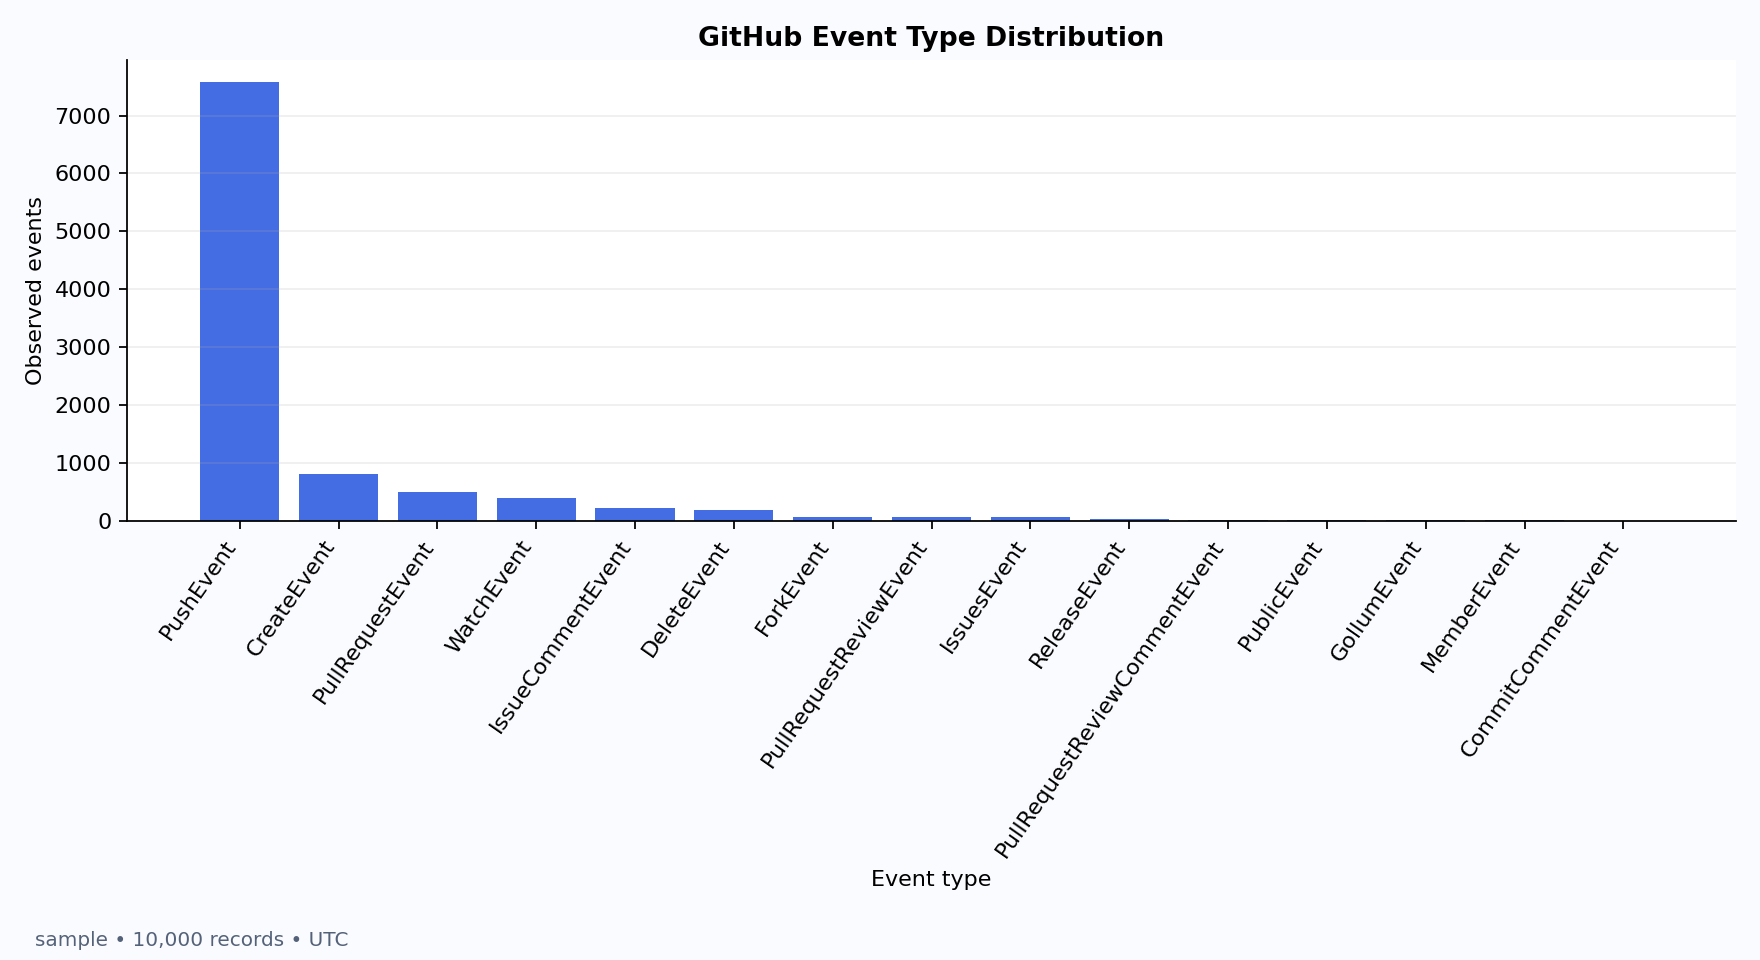

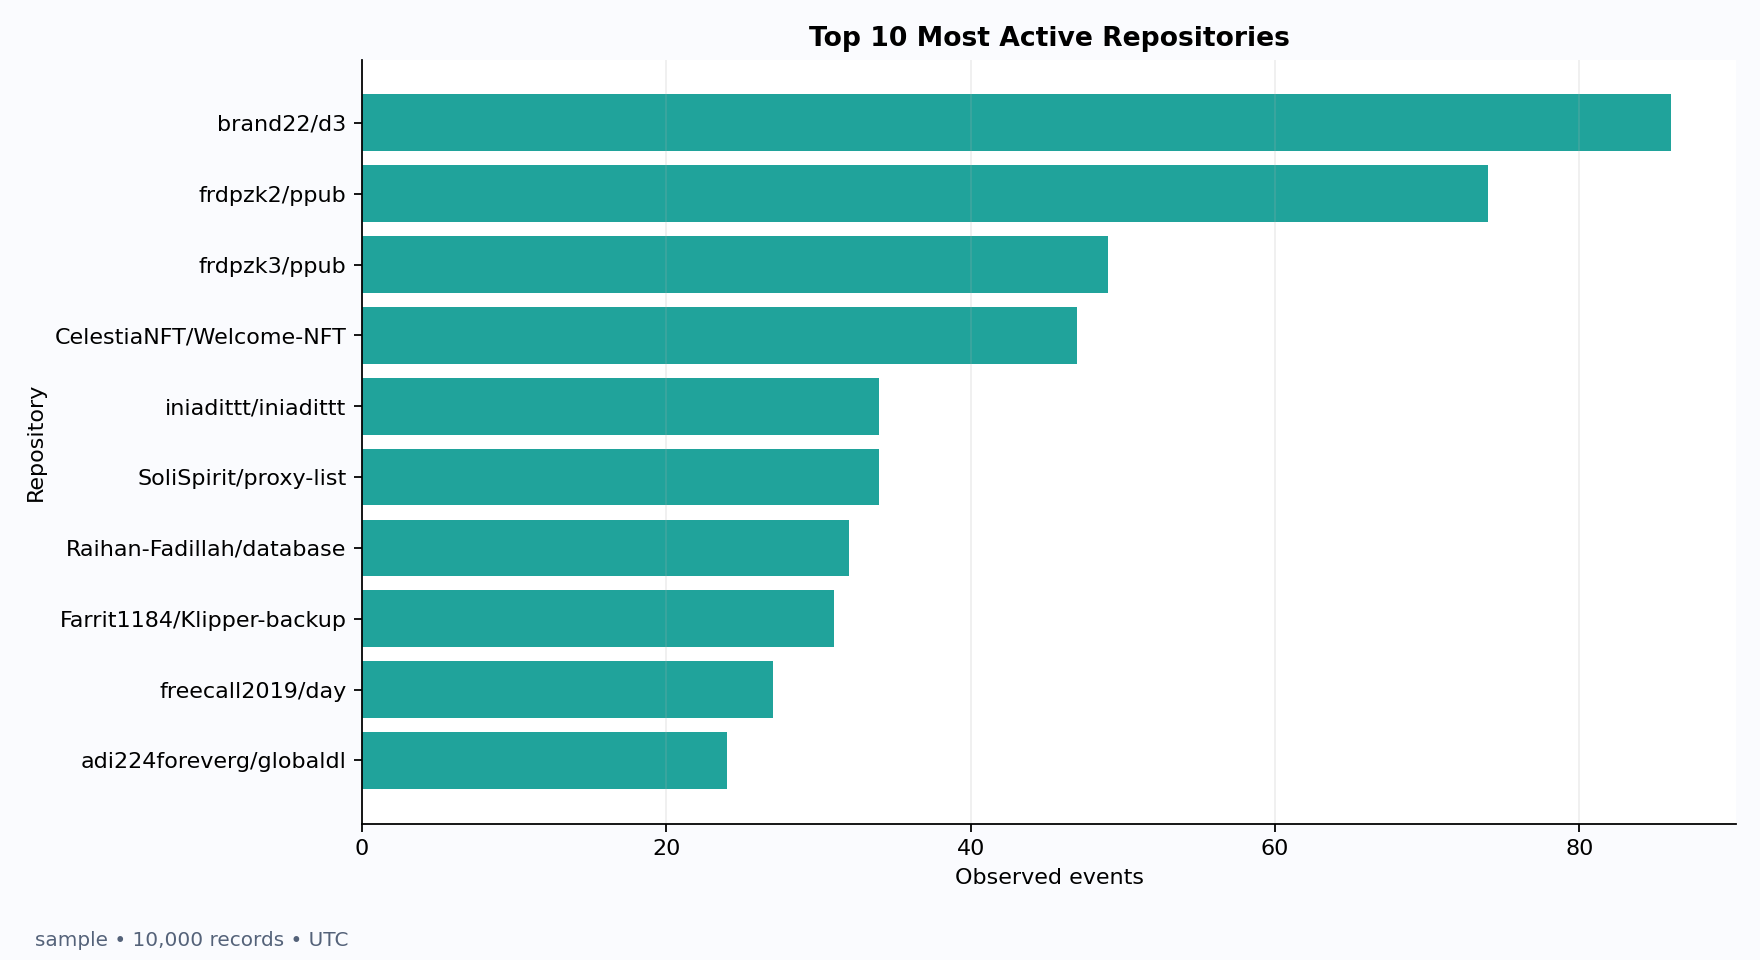

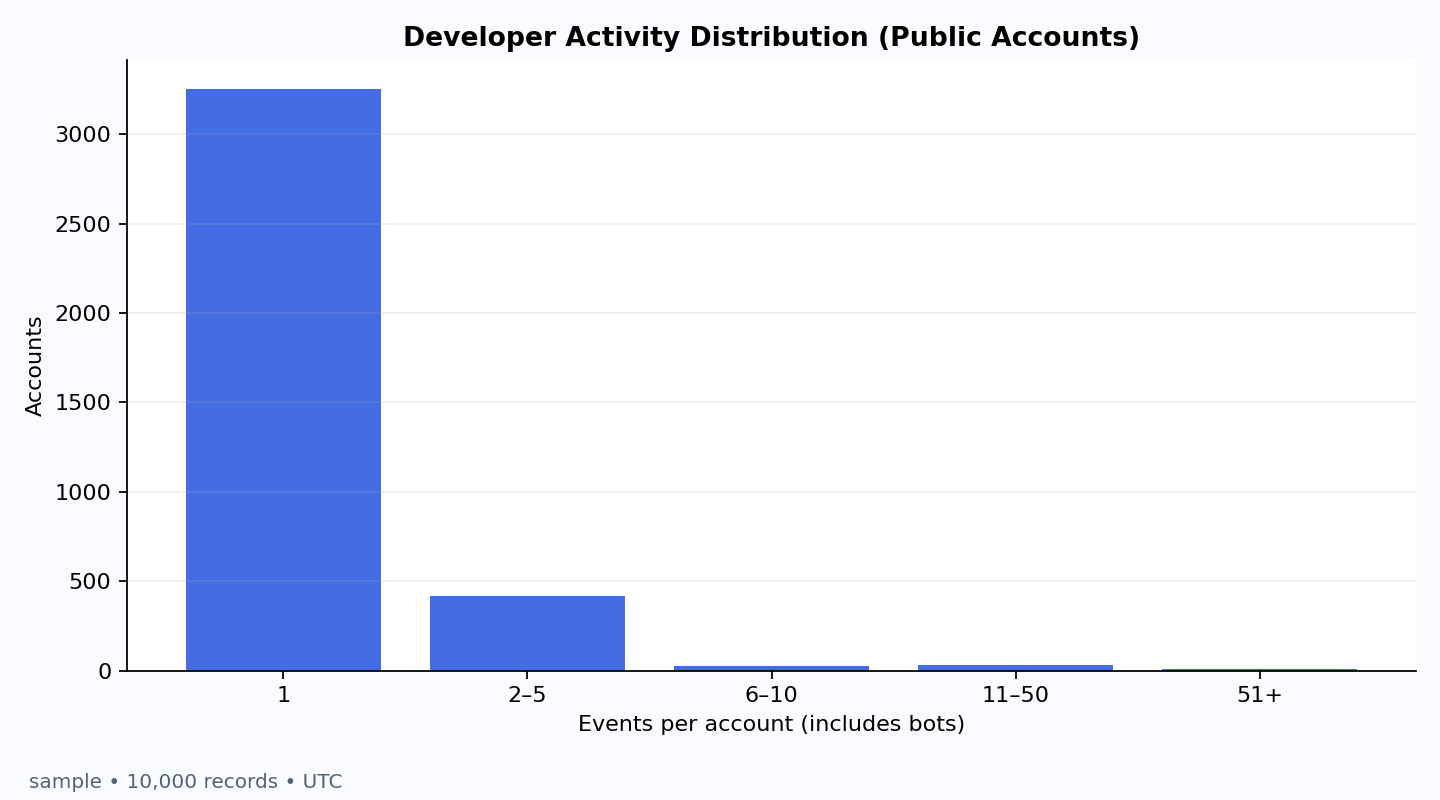

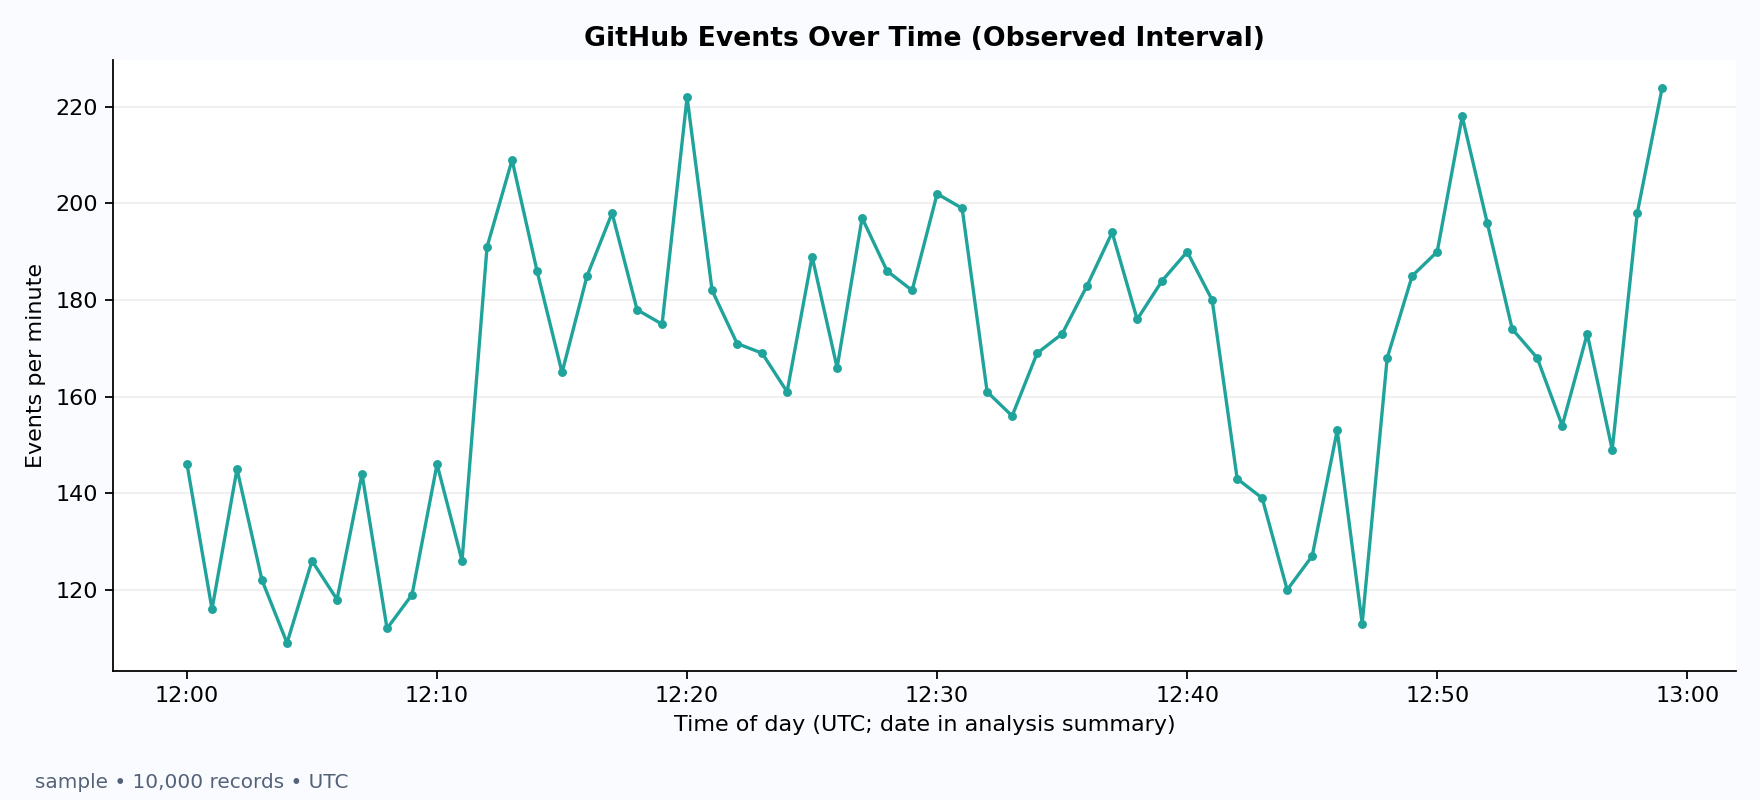

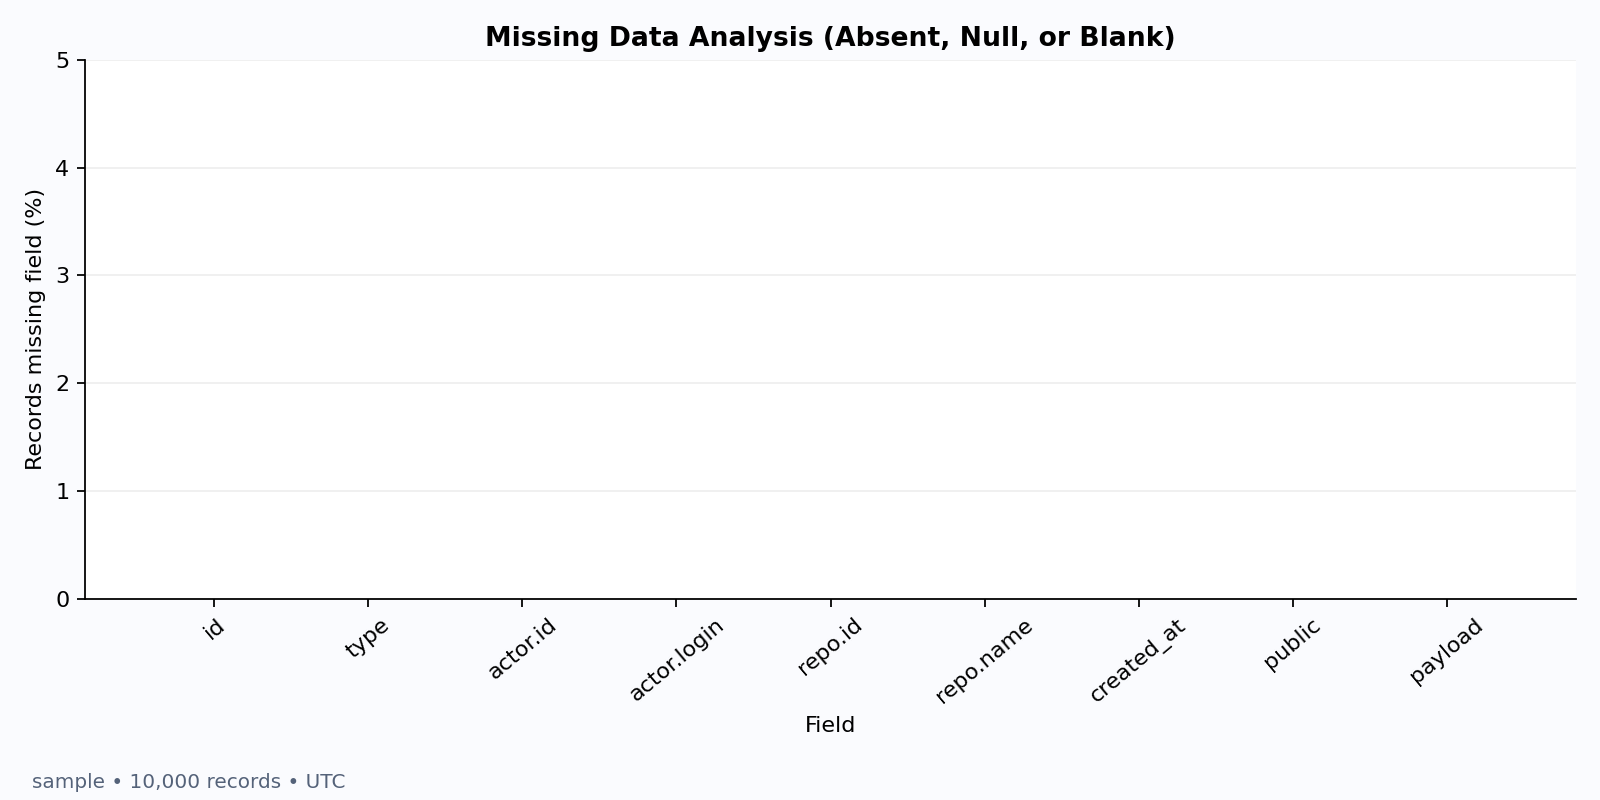

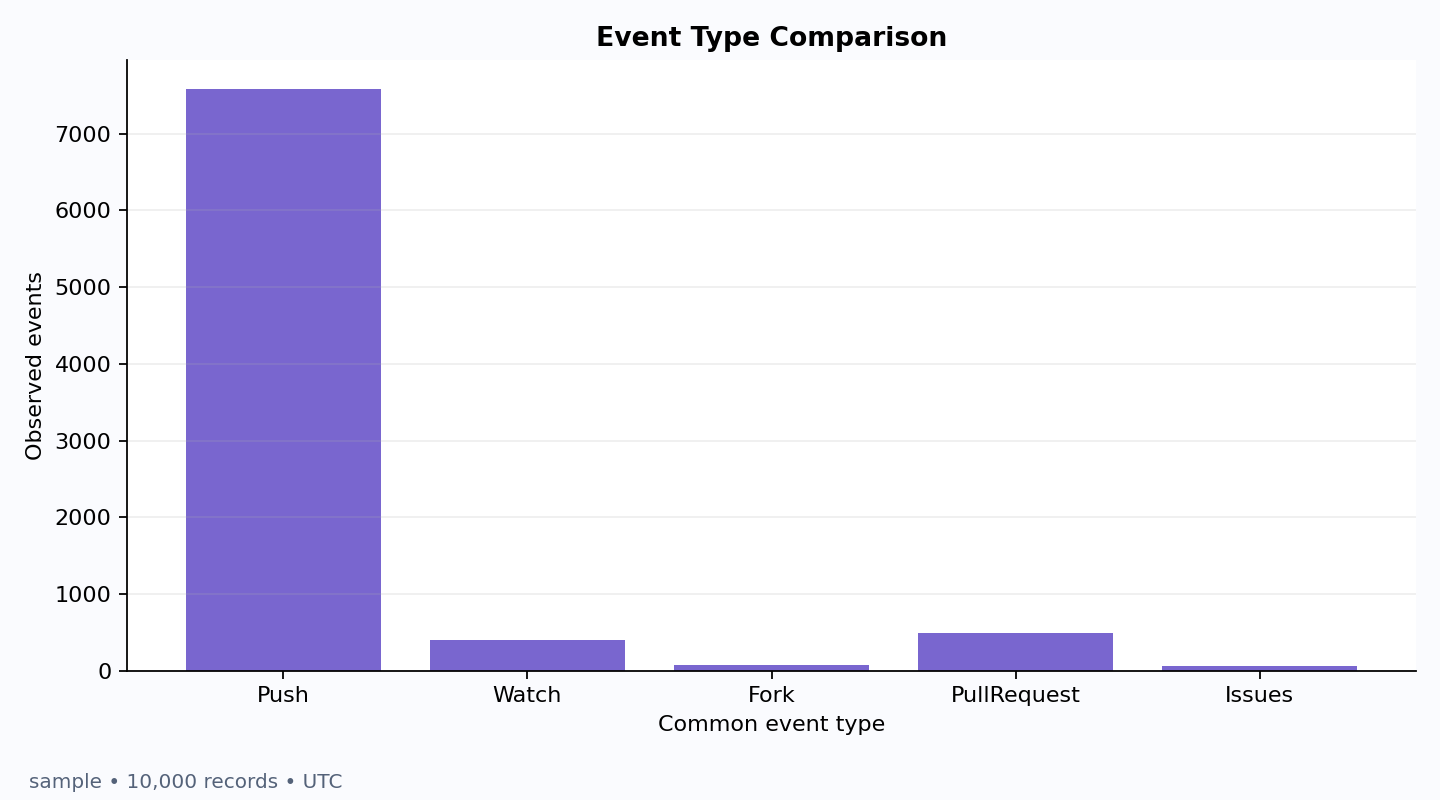

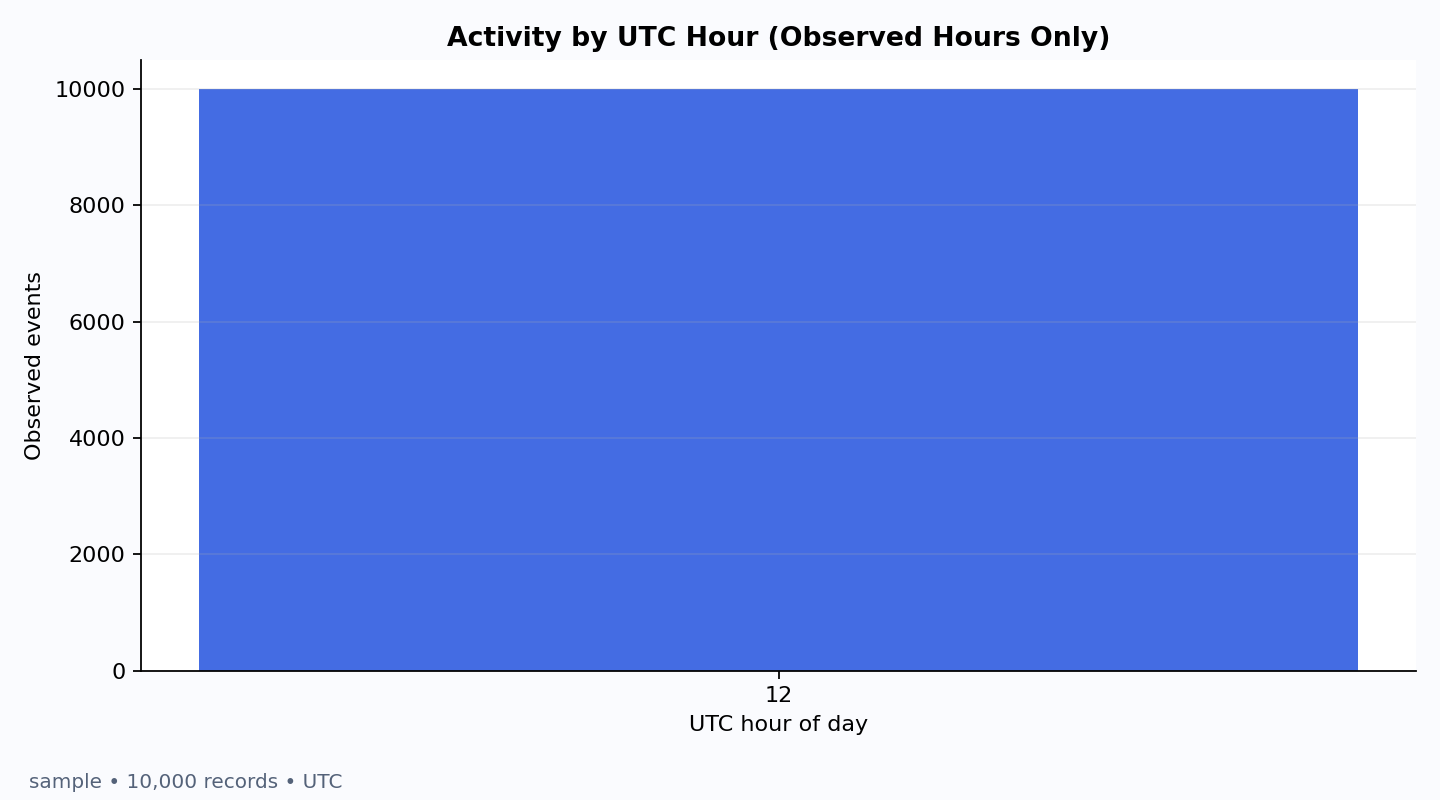

In [8]:
frame, summary, tables = run_analysis(SAMPLE_PATH)
for filename in summary['charts']:
    display(Image(filename=str(CHART_DIR / filename), width=800))

## 11. Introduction to PySpark DataFrames
Pandas is convenient for this small sample in one process. Spark builds an execution
plan and partitions work; local mode demonstrates its API and has startup overhead.
These runs do not establish a speedup or demonstrate a multi-machine cluster.
The helper starts `local[2]`, checks a Python-created DataFrame, reads nested JSON,
prints the inferred schema, selects fields, aggregates, and always stops the session.

In [9]:
spark_result = run_spark_demo(SAMPLE_PATH)
assert spark_result['records'] == summary['records_analyzed']
assert spark_result['event_type_counts'] == summary['event_type_counts']
assert spark_result['unique_repositories'] == summary['unique_repositories_by_id']
assert spark_result['unique_accounts'] == summary['unique_accounts_by_id']
print('Pandas / Spark parity checks passed.')
print((PROCESSED_DIR / 'spark_schema.txt').read_text())
display(pd.Series({k: v for k, v in spark_result.items() if k not in ['transformed_examples', 'event_type_counts']}))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/08 19:10:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+-----------+-----------+-------------+----------------------------------------+---------+----------------+-------------------+------+
|   event_id| event_type|repository_id|                              repository| actor_id|         account|     event_time_utc|public|
+-----------+-----------+-------------+----------------------------------------+---------+----------------+-------------------+------+
|45191299339|  PushEvent|    843767409|                       Bogdan4308/Krokus|157595799|      Bogdan4308|2025-01-01 12:00:00|  true|
|45191299381|  PushEvent|    900338726|                     Dmitro03/Ridne-Font|128385299|        Dmitro03|2025-01-01 12:00:00|  true|
|45191299496|  PushEvent|    910775448|       NarayanaGudiwada/NarayanaGudiwada| 95913215|NarayanaGudiwada|2025-01-01 12:00:01|  true|
|45191299528|CreateEvent|    910779591|ohlitmybad/J_Bellingham_Midfielder_stats|130418672|      ohlitmybad|2025-01-01 12:00:01|  true|
|45191299564|  PushEvent|    910740738|           Mateo

Inferred schema saved to /Users/lalitaditya/Desktop/DevPulse/data/processed/spark_schema.txt
Pandas / Spark parity checks passed.
root
 |-- actor: struct (nullable = true)
 |    |-- avatar_url: string (nullable = true)
 |    |-- display_login: string (nullable = true)
 |    |-- gravatar_id: string (nullable = true)
 |    |-- id: long (nullable = true)
 |    |-- login: string (nullable = true)
 |    |-- url: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- id: string (nullable = true)
 |-- org: struct (nullable = true)
 |    |-- avatar_url: string (nullable = true)
 |    |-- gravatar_id: string (nullable = true)
 |    |-- id: long (nullable = true)
 |    |-- login: string (nullable = true)
 |    |-- url: string (nullable = true)
 |-- payload: struct (nullable = true)
 |    |-- action: string (nullable = true)
 |    |-- before: string (nullable = true)
 |    |-- comment: struct (nullable = true)
 |    |    |-- _links: struct (nullable = true)
 |    |    |    |-- ht

status                                                            passed
spark_version                                                      4.0.1
master                                                          local[2]
java_home                                   /opt/homebrew/opt/openjdk@17
python_worker          /Users/lalitaditya/Desktop/DevPulse/.venv/bin/...
smoke_sum                                                              6
records                                                            10000
unique_repositories                                                 8247
unique_accounts                                                     3738
dtype: object

## 12. Initial Findings and Observations
These observations are generated from the measured sample. The archive's physical
record count is recorded separately from the sample's analyzed record count.

In [10]:
most_common = tables['event_types'].sort_values('events', ascending=False).iloc[0]
display(Markdown(f"Analyzed **{summary['records_analyzed']:,} sampled records** from "
    f"**{metadata['valid_source_records']:,} valid scanned source records**. "
    f"Observed **{summary['unique_repositories_by_id']:,} repository IDs** and "
    f"**{summary['unique_accounts_by_id']:,} account IDs**. "
    f"The most frequent sampled type is **{most_common['event_type']}** "
    f"with **{int(most_common['events']):,} events**. "
    f"There are **{summary['duplicate_excess_records']} excess duplicated-ID records**. "
    f"UTC timestamp range: {summary['timestamp_min_utc']} to {summary['timestamp_max_utc']}."))

Analyzed **10,000 sampled records** from **223,540 valid scanned source records**. Observed **8,247 repository IDs** and **3,738 account IDs**. The most frequent sampled type is **PushEvent** with **7,585 events**. There are **0 excess duplicated-ID records**. UTC timestamp range: 2025-01-01T12:00:00+00:00 to 2025-01-01T12:59:59+00:00.

## 13. Dataset Limitations
- Historical public events exclude private activity and are not a complete productivity record.
- WatchEvent measures observed starring actions, not current cumulative star counts.
- PushEvent is a push event, not a commit count. Payload details can change over time.
- Language metadata is not reliably present across events. Later enrichment must be cached
  and timestamped; no language popularity estimates are invented here.
- Sampling introduces uncertainty, and one holiday hour is not representative of other times.
- API latency and collection timing can make event timestamps differ from archive-hour boundaries.
- Accounts include bots; counts include duplicate records if present. Rare types may be missed.

## 14. Conclusion and Next Steps
Week 1 establishes reproducible bounded collection, schema discovery, quality checks,
Pandas EDA, charts, and local Spark verification. Next, expand controlled ingestion
and design storage/HDFS in Week 2. Distributed ETL, language enrichment, modeling,
streaming, and dashboards follow in later roadmap stages.